Using device: cuda
Experimento: Transformer Preditivo na Lotofácil
Carregados 3601 sorteios
Shape da matriz multi-hot: (3601, 25)
Sequências de treino: (3501, 100, 25)


Epoch 1/50: 100%|██████████| 88/88 [00:17<00:00,  5.15it/s, loss=0.685]


Epoch 1: tr_loss=0.6856, val_loss=0.6828
  -> modelo salvo


Epoch 2/50: 100%|██████████| 88/88 [00:15<00:00,  5.52it/s, loss=0.679]


Epoch 2: tr_loss=0.6795, val_loss=0.6784
  -> modelo salvo


...

Epoch 16: tr_loss=0.6606, val_loss=0.6870


Epoch 17/50: 100%|██████████| 88/88 [00:17<00:00,  4.97it/s, loss=0.648]


Epoch 17: tr_loss=0.6582, val_loss=0.6861


Epoch 18/50: 100%|██████████| 88/88 [00:17<00:00,  4.96it/s, loss=0.664]


Epoch 18: tr_loss=0.6558, val_loss=0.6884
Early stopping.

RESULTADOS FINAIS
Validation loss (modelo): 0.675453
Baseline loss (marginal): 0.672740
Melhoria relativa: -0.40%
Resultados salvos em resultados.csv e modelo_final.pt


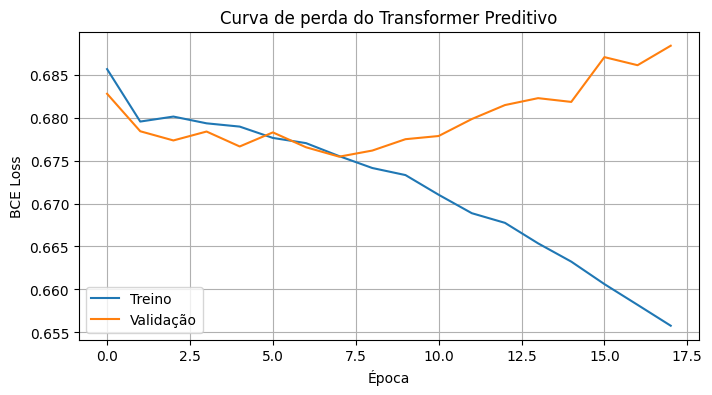

In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""Transformer Causal para Previsão do Próximo Sorteio (Lotofácil)
   Otimizado para Kaggle com 2x T4 GPU (32 GB VRAM)
   Dataset: leonardocpaesbarreto/lotofacil-draws
"""

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import matplotlib.pyplot as plt

# ========== CONFIGURAÇÕES ==========
WINDOW = 100
BATCH_SIZE = 32
D_MODEL = 512
N_LAYERS = 6
N_HEADS = 8
DIM_FF = 2048
DROPOUT = 0.1
LR = 3e-4
MAX_EPOCHS = 50
PATIENCE = 10
N_BITS = 25
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ========== CARREGAMENTO DOS DADOS ==========
def load_lotofacil(path):
    import openpyxl
    if not os.path.exists(path):
        raise FileNotFoundError(f"Arquivo não encontrado: {path}")
    wb = openpyxl.load_workbook(path, data_only=True)
    sheet = wb.active
    rows = list(sheet.iter_rows(values_only=True))
    arr = np.array(rows, dtype=object)
    # Identifica as 15 colunas que contêm números de 1 a 25
    scores = []
    for c in range(arr.shape[1]):
        col = arr[:, c]
        valid = [x for x in col if isinstance(x, (int, float)) and not np.isnan(x)]
        if len(valid) == 0:
            scores.append(0)
        else:
            scores.append(np.mean([(1 <= v <= 25) for v in valid]))
    top15 = np.argsort(scores)[-15:]
    draw_cols = arr[:, sorted(top15)].astype(float)
    valid_rows = []
    for row in draw_cols:
        row_int = row[~np.isnan(row)].astype(int)
        if len(row_int) >= 15 and len(set(row_int[:15])) >= 14 and all(1 <= v <= 25 for v in row_int[:15]):
            valid_rows.append(row_int[:15])
    X = np.zeros((len(valid_rows), N_BITS), dtype=np.float32)
    for i, row in enumerate(valid_rows):
        for v in row:
            X[i, int(v)-1] = 1.0
    print(f"Carregados {len(valid_rows)} sorteios")
    return X

def make_sequences(X, window=WINDOW):
    inputs, targets = [], []
    for i in range(len(X) - window):
        inputs.append(X[i:i+window])
        targets.append(X[i+window])
    return np.array(inputs, dtype=np.float32), np.array(targets, dtype=np.float32)

# ========== MODELO TRANSFORMER CAUSAL ==========
class CausalTransformer(nn.Module):
    def __init__(self, in_dim, d_model, n_heads, n_layers, dim_ff, dropout):
        super().__init__()
        self.embedding = nn.Linear(in_dim, d_model)
        self.pos_enc = nn.Parameter(torch.randn(1, WINDOW, d_model) * 0.02)
        decoder_layer = nn.TransformerDecoderLayer(d_model, n_heads, dim_ff, dropout, batch_first=True)
        self.decoder = nn.TransformerDecoder(decoder_layer, n_layers)
        self.out_proj = nn.Linear(d_model, in_dim)

    def forward(self, x):
        B, T, _ = x.shape
        causal_mask = torch.triu(torch.ones(T, T) * float('-inf'), diagonal=1).to(x.device)
        z = self.embedding(x) + self.pos_enc[:, :T, :]
        out = self.decoder(z, z, tgt_mask=causal_mask)
        return self.out_proj(out)

    def predict_next(self, x):
        out = self.forward(x)
        return out[:, -1, :]

# ========== BASELINE MARGINAL ==========
def marginal_baseline_loss(targets, marginal_probs):
    bce = nn.BCEWithLogitsLoss(reduction='none')
    logits = torch.logit(torch.tensor(marginal_probs, device=targets.device))
    logits = logits.expand(targets.shape[0], -1)
    return bce(logits, targets).mean()

# ========== TREINAMENTO ==========
def train_model(train_loader, val_loader, model, criterion, optimizer, scheduler, epochs, patience):
    best_val_loss = float('inf')
    patience_cnt = 0
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        tr_loss = 0.0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for xb, yb in loop:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model.predict_next(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tr_loss += loss.item() * len(xb)
            loop.set_postfix(loss=loss.item())
        tr_loss /= len(train_loader.dataset)
        train_losses.append(tr_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                pred = model.predict_next(xb)
                loss = criterion(pred, yb)
                val_loss += loss.item() * len(xb)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        scheduler.step()
        print(f"Epoch {epoch+1}: tr_loss={tr_loss:.4f}, val_loss={val_loss:.4f}")

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            patience_cnt = 0
            torch.save(model.state_dict(), "best_model.pt")
            print("  -> modelo salvo")
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print("Early stopping.")
                break
    model.load_state_dict(torch.load("best_model.pt"))
    return model, train_losses, val_losses

def get_dataloaders(inputs, targets, initial_batch=32):
    global BATCH_SIZE
    while True:
        try:
            loader = DataLoader(TensorDataset(torch.tensor(inputs), torch.tensor(targets)), 
                                batch_size=initial_batch, shuffle=True)
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                del xb, yb
                torch.cuda.empty_cache()
                break
            BATCH_SIZE = initial_batch
            return loader
        except RuntimeError as e:
            if "out of memory" in str(e):
                initial_batch //= 2
                if initial_batch < 2:
                    raise RuntimeError("GPU out of memory mesmo com batch_size=2.")
                print(f"Batch size {initial_batch*2} causou OOM. Reduzindo para {initial_batch}...")
                torch.cuda.empty_cache()
            else:
                raise e

# ========== MAIN ==========
def main():
    print("="*60)
    print("Experimento: Transformer Preditivo na Lotofácil")
    print("="*60)

    # CAMINHO FIXO CONFORME SOLICITADO
    caminho_excel = '/kaggle/input/datasets/leonardocpaesbarreto/lotofacil-draws/Lotofacil.xlsx'
    
    X = load_lotofacil(caminho_excel)
    print(f"Shape da matriz multi-hot: {X.shape}")

    inputs, targets = make_sequences(X)
    print(f"Sequências de treino: {inputs.shape}")

    split = int(0.8 * len(inputs))
    train_in, val_in = inputs[:split], inputs[split:]
    train_tar, val_tar = targets[:split], targets[split:]

    train_loader = get_dataloaders(train_in, train_tar, initial_batch=BATCH_SIZE)
    val_loader = DataLoader(TensorDataset(torch.tensor(val_in), torch.tensor(val_tar)), 
                            batch_size=BATCH_SIZE, shuffle=False)

    model = CausalTransformer(N_BITS, D_MODEL, N_HEADS, N_LAYERS, DIM_FF, DROPOUT).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

    model, train_losses, val_losses = train_model(train_loader, val_loader, model, criterion, optimizer, scheduler, MAX_EPOCHS, PATIENCE)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model.predict_next(xb)
            val_loss += criterion(pred, yb).item() * len(xb)
    val_loss /= len(val_loader.dataset)

    marginal_probs = X.mean(axis=0)
    baseline_loss = marginal_baseline_loss(torch.tensor(val_tar), marginal_probs).item()
    improvement = (baseline_loss - val_loss) / baseline_loss * 100

    print("\n" + "="*60)
    print("RESULTADOS FINAIS")
    print("="*60)
    print(f"Validation loss (modelo): {val_loss:.6f}")
    print(f"Baseline loss (marginal): {baseline_loss:.6f}")
    print(f"Melhoria relativa: {improvement:.2f}%")

    plt.figure(figsize=(8,4))
    plt.plot(train_losses, label='Treino')
    plt.plot(val_losses, label='Validação')
    plt.xlabel('Época')
    plt.ylabel('BCE Loss')
    plt.title('Curva de perda do Transformer Preditivo')
    plt.legend()
    plt.grid(True)
    plt.savefig('loss_curve.png', dpi=150)

    pd.DataFrame([{'val_loss': val_loss, 'baseline_loss': baseline_loss, 'improvement_pct': improvement}]).to_csv('resultados.csv', index=False)
    torch.save(model.state_dict(), 'modelo_final.pt')
    print("Resultados salvos em resultados.csv e modelo_final.pt")

if __name__ == "__main__":
    main()